### Setup and Import Libraries

In [1]:
print("=" * 60)
print("DATA PREPROCESSING FOR FRAUD DETECTION SYSTEM")
print("=" * 60)

# Data manipulation
import pandas as pd
import numpy as np

# Visualization 
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
import sklearn
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# Handling imbalanced data
from imblearn.over_sampling import SMOTE

# Save the scaler
import joblib
import json

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Path handling
from pathlib import Path

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("All libraries imported successfully!")

DATA PREPROCESSING FOR FRAUD DETECTION SYSTEM
All libraries imported successfully!


### Setup Paths and Load Data


In [2]:
# Setup paths
PROJECT_ROOT = Path.cwd().parent
ARTIFACTS_DIR = PROJECT_ROOT / 'artifacts'
RAW_DATA_DIR = ARTIFACTS_DIR / 'raw'
PROCESSED_DATA_DIR = ARTIFACTS_DIR / 'processed'

# Create processed directory if it doesn't exist
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)

# Load the dataset
raw_file = RAW_DATA_DIR / 'Synthetic_Financial_datasets_log.csv'

# If the file has different name, list files
if not raw_file.exists():
    print("Looking for CSV files in raw directory:")
    csv_files = list(RAW_DATA_DIR.glob('*.csv'))
    for f in csv_files:
        print(f"  - {f.name}")
    if csv_files:
        raw_file = csv_files[0]

print(f"\nLoading dataset from: {raw_file}")
df = pd.read_csv(raw_file)
print(f"Loaded {len(df):,} rows and {len(df.columns)} columns")


Loading dataset from: d:\AI_Project\AI_Financial_Fraud_Detection\artifacts\raw\Synthetic_Financial_datasets_log.csv
Loaded 6,362,620 rows and 11 columns


### Initial Data Inspection

In [3]:
print("=" * 60)
print("INITIAL DATA INSPECTION")
print("=" * 60)

print("\n1. First 5 rows:")
display(df.head())

print("\n2. Last 5 rows:")
display(df.tail())

print("\n3. Data types:")
print(df.dtypes)

print("\n4. Missing values:")
missing = df.isnull().sum()
if missing.sum() > 0:
    print(missing[missing > 0])
else:
    print("No missing values found")

print("\n5. Duplicate rows:")
duplicates = df.duplicated().sum()
print(f"Duplicate rows: {duplicates}")

print("\n6. Dataset shape:")
print(f"Rows: {len(df):,}, Columns: {len(df.columns)}")

INITIAL DATA INSPECTION

1. First 5 rows:


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0



2. Last 5 rows:


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.0,C776919290,0.00,339682.13,1,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.0,C1881841831,0.00,0.00,1,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.0,C1365125890,68488.84,6379898.11,1,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.0,C2080388513,0.00,0.00,1,0
6362619,743,CASH_OUT,850002.52,C1280323807,850002.52,0.0,C873221189,6510099.11,7360101.63,1,0



3. Data types:
step                int64
type               object
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object

4. Missing values:
No missing values found

5. Duplicate rows:
Duplicate rows: 0

6. Dataset shape:
Rows: 6,362,620, Columns: 11


### Drop Unnecessary Columns

In [4]:
print("=" * 60)
print("DROP BALANCE COLUMNS")
print("=" * 60)

print("Original columns:")
print(list(df.columns))

columns_to_drop = ['oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']

print(f"\nDropping columns: {columns_to_drop}")

df_cleaned = df.drop(columns=columns_to_drop)

print(f"\nRemaining columns: {list(df_cleaned.columns)}")
print(f"New shape: {df_cleaned.shape}")

DROP BALANCE COLUMNS
Original columns:
['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']

Dropping columns: ['oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']

Remaining columns: ['step', 'type', 'amount', 'nameOrig', 'nameDest', 'isFraud', 'isFlaggedFraud']
New shape: (6362620, 7)


### Remove Duplicates

In [5]:
print("=" * 60)
print("REMOVE DUPLICATES")
print("=" * 60)

initial_rows = len(df_cleaned)
duplicate_count = df_cleaned.duplicated().sum()
print(f"Duplicate rows found: {duplicate_count}")

if duplicate_count > 0:
    df_cleaned = df_cleaned.drop_duplicates()
    print(f"Rows after removal: {len(df_cleaned)}")
else:
    print("No duplicates found")
    
print(f"Final shape: {df_cleaned.shape}")

REMOVE DUPLICATES
Duplicate rows found: 0
No duplicates found
Final shape: (6362620, 7)


### One-Hot Encode Transaction Type

In [6]:
print("=" * 60)
print("ONE-HOT ENCODING FOR TRANSACTION TYPE")
print("=" * 60)

print("Transaction types before encoding:")
print(df_cleaned['type'].value_counts())

type_dummies = pd.get_dummies(df_cleaned['type'], prefix='type')
df_encoded = pd.concat([df_cleaned, type_dummies], axis=1)
df_encoded = df_encoded.drop('type', axis=1)

print(f"\nNew columns added: {list(type_dummies.columns)}")
print(f"New shape: {df_encoded.shape}")
print("\nFirst 2 rows after encoding:")
display(df_encoded.head(2))

ONE-HOT ENCODING FOR TRANSACTION TYPE
Transaction types before encoding:
type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

New columns added: ['type_CASH_IN', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER']
New shape: (6362620, 11)

First 2 rows after encoding:


,step,amount,nameOrig,nameDest,isFraud,isFlaggedFraud,type_CASH_IN,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,1,9839.64,C1231006815,M1979787155,0,0,False,False,False,True,False
1,1,1864.28,C1666544295,M2044282225,0,0,False,False,False,True,False


### Convert Boolean to Integer and Verify Encoding

In [7]:
print("=" * 60)
print("CONVERT BOOLEAN TO INTEGER AND VERIFY ENCODING")
print("=" * 60)

# Convert boolean columns to integer (0/1)
type_cols = [col for col in df_encoded.columns if col.startswith('type_')]
for col in type_cols:
    df_encoded[col] = df_encoded[col].astype(int)

print(f"Type indicator columns converted to integer: {type_cols}")

# Verify conversion
print("\nFirst 2 rows after conversion:")
display(df_encoded.head(2))

# Verify row sums
row_sums = df_encoded[type_cols].sum(axis=1)
print(f"\nAll rows have exactly one type indicator: {(row_sums == 1).all()}")

# Check fraud distribution by type
fraud_mask = df_encoded['isFraud'] == 1
for col in type_cols:
    fraud_count_in_type = df_encoded[fraud_mask][col].sum()
    if fraud_count_in_type > 0:
        percentage = fraud_count_in_type / df_encoded[fraud_mask].shape[0] * 100
        print(f"{col}: {int(fraud_count_in_type)} fraudulent transactions ({percentage:.1f}% of all frauds)")

CONVERT BOOLEAN TO INTEGER AND VERIFY ENCODING
Type indicator columns converted to integer: ['type_CASH_IN', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER']

First 2 rows after conversion:


,step,amount,nameOrig,nameDest,isFraud,isFlaggedFraud,type_CASH_IN,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,1,9839.64,C1231006815,M1979787155,0,0,0,0,0,1,0
1,1,1864.28,C1666544295,M2044282225,0,0,0,0,0,1,0



All rows have exactly one type indicator: True
type_CASH_OUT: 4116 fraudulent transactions (50.1% of all frauds)
type_TRANSFER: 4097 fraudulent transactions (49.9% of all frauds)


### Feature Engineering

In [8]:
print("=" * 60)
print("FEATURE ENGINEERING")
print("=" * 60)

# Build only features that do NOT require target labels or future-history assumptions.
print("\nCreating leakage-safe base features...")

# Temporal features are safe because they come directly from timestamp-like step.
df_encoded['hour_of_cycle'] = df_encoded['step'] % 24
df_encoded['day_of_cycle'] = (df_encoded['step'] // 24).astype(int)

print("  Added: hour_of_cycle, day_of_cycle")
print(f"  Step range (hours): {df_encoded['step'].min():.0f}-{df_encoded['step'].max():.0f}")

# Leakage-prone features will be created AFTER train/val/test split using train-only fitting.
print("\nDeferred until after split:")
print("  - sender_transaction_count")
print("  - is_first_transaction")
print("  - dest_fraud_rate")
print("  - transaction-type average deviation")
print("  - high_amount_to_fraud_dest")

print(f"\nCurrent shape after base feature engineering: {df_encoded.shape}")

FEATURE ENGINEERING

Creating leakage-safe base features...
  Added: hour_of_cycle, day_of_cycle
  Step range (hours): 1-743

Deferred until after split:
  - sender_transaction_count
  - is_first_transaction
  - dest_fraud_rate
  - transaction-type average deviation
  - high_amount_to_fraud_dest

Current shape after base feature engineering: (6362620, 13)


### Feature Scaling

In [9]:
# Scaling must be fitted on training data only (after split).
print("=" * 60)
print("FEATURE SCALING")
print("=" * 60)

# Keep this list to reuse after split when fitting scaler on train only.
exclude_cols = ['nameOrig', 'nameDest', 'isFraud', 'isFlaggedFraud']
type_cols = [col for col in df_encoded.columns if col.startswith('type_')]
flag_cols = [col for col in df_encoded.columns if col.startswith('is_')]
exclude_cols.extend(type_cols)
exclude_cols.extend(flag_cols)

numerical_cols = df_encoded.select_dtypes(include=[np.number]).columns
cols_to_scale = [col for col in numerical_cols if col not in exclude_cols]

print("Scaling is intentionally deferred to prevent leakage.")
print(f"Candidate columns to scale later: {cols_to_scale}")
print(f"Excluded binary/categorical columns: {[col for col in exclude_cols if col in df_encoded.columns]}")

FEATURE SCALING
Scaling is intentionally deferred to prevent leakage.
Candidate columns to scale later: ['step', 'amount', 'hour_of_cycle', 'day_of_cycle']
Excluded binary/categorical columns: ['nameOrig', 'nameDest', 'isFraud', 'isFlaggedFraud', 'type_CASH_IN', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER']


### Class Distribution Check

In [10]:
print("=" * 60)
print("CLASS DISTRIBUTION")
print("=" * 60)

fraud_count = (df_encoded['isFraud'] == 1).sum()
legit_count = (df_encoded['isFraud'] == 0).sum()
total = len(df_encoded)

print(f"Total transactions: {total:,}")
print(f"Legitimate transactions: {legit_count:,} ({legit_count/total*100:.4f}%)")
print(f"Fraudulent transactions: {fraud_count:,} ({fraud_count/total*100:.4f}%)")
print(f"Imbalance ratio: 1:{legit_count/fraud_count:.2f}")

CLASS DISTRIBUTION
Total transactions: 6,362,620
Legitimate transactions: 6,354,407 (99.8709%)
Fraudulent transactions: 8,213 (0.1291%)
Imbalance ratio: 1:773.70


### Prepare Base Data 

In [11]:
# Prepare base features and target
print("=" * 60)
print("PREPARE BASE DATA")
print("=" * 60)

# Exclude isFlaggedFraud to prevent leakage
base_feature_cols = [
    col for col in df_encoded.columns
    if col not in ['isFraud', 'nameOrig', 'nameDest', 'isFlaggedFraud']
]

X_base = df_encoded[base_feature_cols]
y_base = df_encoded['isFraud']

# Keep compatibility with later cells that reference X/y
X = X_base
y = y_base

print(f"Base features shape: {X_base.shape}")
print(f"Target shape: {y_base.shape}")
print(f"Number of base features: {len(base_feature_cols)}")

print("\nIMPORTANT: isFlaggedFraud excluded to prevent leakage")
print("Additional engineered features that need target/train-only fitting will be added after split.")

PREPARE BASE DATA
Base features shape: (6362620, 9)
Target shape: (6362620,)
Number of base features: 9

IMPORTANT: isFlaggedFraud excluded to prevent leakage
Additional engineered features that need target/train-only fitting will be added after split.


### Implement Class Weights 

In [12]:
# Class weights should be computed from train split only.
print("=" * 60)
print("CLASS WEIGHTS (DEFERRED)")
print("=" * 60)
print("Class weights will be computed after split-aware feature engineering.")
print("This avoids any train/validation/test contamination.")

CLASS WEIGHTS (DEFERRED)
Class weights will be computed after split-aware feature engineering.
This avoids any train/validation/test contamination.


### Train/Validation/Test Split

In [13]:
# Train/Validation/Test Split (70:15:15)
print("=" * 60)
print("TRAIN/VALIDATION/TEST SPLIT")
print("=" * 60)

# Split row indices first (memory-safe)
all_idx = np.arange(len(y_base), dtype=np.int32)
y_np = y_base.to_numpy(copy=False)

# First split: test set (15%)
train_val_idx, test_idx = train_test_split(
    all_idx,
    test_size=0.15,
    random_state=42,
    stratify=y_np
)

# Second split: validation set from remaining (15% of original, ~17.65% of train_val)
train_idx, val_idx = train_test_split(
    train_val_idx,
    test_size=0.17647,  # 15% of original / 85% ≈ 0.17647
    random_state=42,
    stratify=y_np[train_val_idx]
)

# Materialize split dataframes (retain identifier columns for leakage-safe feature engineering)
train_df = df_encoded.iloc[train_idx].copy()
val_df = df_encoded.iloc[val_idx].copy()
test_df = df_encoded.iloc[test_idx].copy()

# Sort by sender-time for causal feature construction
train_df = train_df.sort_values(['nameOrig', 'step'])
val_df = val_df.sort_values(['nameOrig', 'step'])
test_df = test_df.sort_values(['nameOrig', 'step'])

print(f"Total samples: {len(df_encoded):,}")
print(f"Training set: {train_df.shape[0]:,} samples ({train_df.shape[0]/len(df_encoded)*100:.1f}%)")
print(f"Validation set: {val_df.shape[0]:,} samples ({val_df.shape[0]/len(df_encoded)*100:.1f}%)")
print(f"Test set: {test_df.shape[0]:,} samples ({test_df.shape[0]/len(df_encoded)*100:.1f}%)")

print("\nTraining set class distribution:")
print(f"  Class 0: {(train_df['isFraud'] == 0).sum():,} ({(train_df['isFraud'] == 0).mean()*100:.2f}%)")
print(f"  Class 1: {(train_df['isFraud'] == 1).sum():,} ({(train_df['isFraud'] == 1).mean()*100:.2f}%)")

print("\nValidation set class distribution:")
print(f"  Class 0: {(val_df['isFraud'] == 0).sum():,} ({(val_df['isFraud'] == 0).mean()*100:.2f}%)")
print(f"  Class 1: {(val_df['isFraud'] == 1).sum():,} ({(val_df['isFraud'] == 1).mean()*100:.2f}%)")

print("\nTest set class distribution:")
print(f"  Class 0: {(test_df['isFraud'] == 0).sum():,} ({(test_df['isFraud'] == 0).mean()*100:.2f}%)")
print(f"  Class 1: {(test_df['isFraud'] == 1).sum():,} ({(test_df['isFraud'] == 1).mean()*100:.2f}%)")

TRAIN/VALIDATION/TEST SPLIT
Total samples: 6,362,620
Training set: 4,453,837 samples (70.0%)
Validation set: 954,390 samples (15.0%)
Test set: 954,393 samples (15.0%)

Training set class distribution:
  Class 0: 4,448,088 (99.87%)
  Class 1: 5,749 (0.13%)

Validation set class distribution:
  Class 0: 953,158 (99.87%)
  Class 1: 1,232 (0.13%)

Test set class distribution:
  Class 0: 953,161 (99.87%)
  Class 1: 1,232 (0.13%)


### Train/Test Data Leakage Validation

In [14]:
print("=" * 60)
print("POST-SPLIT LEAKAGE-SAFE FEATURE ENGINEERING AND SCALING")
print("=" * 60)

# 1) Sender behavioral features (causal within each split)
for part in [train_df, val_df, test_df]:
    part['sender_transaction_count'] = part.groupby('nameOrig').cumcount() + 1
    part['is_first_transaction'] = (part['sender_transaction_count'] == 1).astype(int)

# 2) Destination fraud rate using TRAIN ONLY target statistics
global_train_fraud_rate = train_df['isFraud'].mean()
dest_rate_train = train_df.groupby('nameDest')['isFraud'].mean()

train_df['dest_fraud_rate'] = train_df['nameDest'].map(dest_rate_train).fillna(global_train_fraud_rate)
val_df['dest_fraud_rate'] = val_df['nameDest'].map(dest_rate_train).fillna(global_train_fraud_rate)
test_df['dest_fraud_rate'] = test_df['nameDest'].map(dest_rate_train).fillna(global_train_fraud_rate)

# 3) Transaction-type amount deviation from TRAIN ONLY
type_cols_local = [c for c in train_df.columns if c.startswith('type_')]
for trans_type in type_cols_local:
    avg_amount_by_type = train_df.loc[train_df[trans_type] == 1, 'amount'].mean()
    if pd.isna(avg_amount_by_type):
        avg_amount_by_type = train_df['amount'].mean()

    train_df[f'{trans_type}_avg_deviation'] = (train_df['amount'] - avg_amount_by_type) * train_df[trans_type]
    val_df[f'{trans_type}_avg_deviation'] = (val_df['amount'] - avg_amount_by_type) * val_df[trans_type]
    test_df[f'{trans_type}_avg_deviation'] = (test_df['amount'] - avg_amount_by_type) * test_df[trans_type]

# 4) Interaction thresholds from TRAIN ONLY
amount_q75 = train_df['amount'].quantile(0.75)
dest_q75 = train_df['dest_fraud_rate'].quantile(0.75)
for part in [train_df, val_df, test_df]:
    part['high_amount_to_fraud_dest'] = (
        (part['amount'] > amount_q75).astype(int)
        * (part['dest_fraud_rate'] > dest_q75).astype(int)
    )

# 5) Build model feature matrices
feature_cols = [
    c for c in train_df.columns
    if c not in ['isFraud', 'nameOrig', 'nameDest', 'isFlaggedFraud']
]

X_train = train_df[feature_cols].copy()
X_val = val_df[feature_cols].copy()
X_test = test_df[feature_cols].copy()

y_train = train_df['isFraud'].copy()
y_val = val_df['isFraud'].copy()
y_test = test_df['isFraud'].copy()

# 6) Fit scaler on TRAIN ONLY
exclude_scale = [c for c in X_train.columns if c.startswith('type_') or c.startswith('is_')]
cols_to_scale_fix = [c for c in X_train.select_dtypes(include=[np.number]).columns if c not in exclude_scale]

# Ensure numeric scaled columns are float to avoid pandas dtype assignment errors
for part in [X_train, X_val, X_test]:
    part[cols_to_scale_fix] = part[cols_to_scale_fix].astype('float64')

scaler = StandardScaler()
X_train.loc[:, cols_to_scale_fix] = scaler.fit_transform(X_train[cols_to_scale_fix])
X_val.loc[:, cols_to_scale_fix] = scaler.transform(X_val[cols_to_scale_fix])
X_test.loc[:, cols_to_scale_fix] = scaler.transform(X_test[cols_to_scale_fix])

# 7) Compute class weights from TRAIN ONLY
from sklearn.utils.class_weight import compute_class_weight
classes = np.unique(y_train)
class_weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = {int(classes[0]): float(class_weights[0]), int(classes[1]): float(class_weights[1])}

# 8) Basic leakage checks
train_senders = set(train_df['nameOrig'].unique())
val_senders = set(val_df['nameOrig'].unique())
test_senders = set(test_df['nameOrig'].unique())
train_test_overlap = len(train_senders.intersection(test_senders))
train_val_overlap = len(train_senders.intersection(val_senders))
test_val_overlap = len(test_senders.intersection(val_senders))

print("\nCustomer overlap check:")
print(f"  Train-Test overlap: {train_test_overlap}")
print(f"  Train-Val overlap: {train_val_overlap}")
print(f"  Test-Val overlap: {test_val_overlap}")

print("\nFraud rates by split:")
print(f"  Train: {y_train.mean()*100:.4f}%")
print(f"  Val:   {y_val.mean()*100:.4f}%")
print(f"  Test:  {y_test.mean()*100:.4f}%")

print("\nClass weights (train only):")
print(f"  Class 0: {class_weight_dict[0]:.4f}")
print(f"  Class 1: {class_weight_dict[1]:.4f}")

print("\nLeakage-safe feature engineering and scaling complete")

POST-SPLIT LEAKAGE-SAFE FEATURE ENGINEERING AND SCALING

Customer overlap check:
  Train-Test overlap: 1992
  Train-Val overlap: 1942
  Test-Val overlap: 388

Fraud rates by split:
  Train: 0.1291%
  Val:   0.1291%
  Test:  0.1291%

Class weights (train only):
  Class 0: 0.5006
  Class 1: 387.3575

Leakage-safe feature engineering and scaling complete


### Feature Correlation Analysis

FEATURE CORRELATION ANALYSIS

Calculating feature correlations with fraud target...

Top 10 Features (Most Correlated with Fraud):
 1. dest_fraud_rate                    :  0.7061 ↑ Positive
 2. high_amount_to_fraud_dest          :  0.4053 ↑ Positive
 3. type_CASH_OUT_avg_deviation        :  0.2193 ↑ Positive
 4. amount                             :  0.0772 ↑ Positive
 5. type_TRANSFER                      :  0.0537 ↑ Positive
 6. day_of_cycle                       :  0.0335 ↑ Positive
 7. step                               :  0.0325 ↑ Positive
 8. type_TRANSFER_avg_deviation        :  0.0196 ↑ Positive
 9. type_CASH_OUT                      :  0.0113 ↑ Positive
10. sender_transaction_count           :  0.0008 ↑ Positive

Bottom 10 Features (Least Correlated with Fraud):
18. type_CASH_OUT                      :  0.0113 ↑ Positive
17. sender_transaction_count           :  0.0008 ↑ Positive
16. type_PAYMENT_avg_deviation         :  0.0000 ↑ Positive
15. type_DEBIT_avg_deviation          

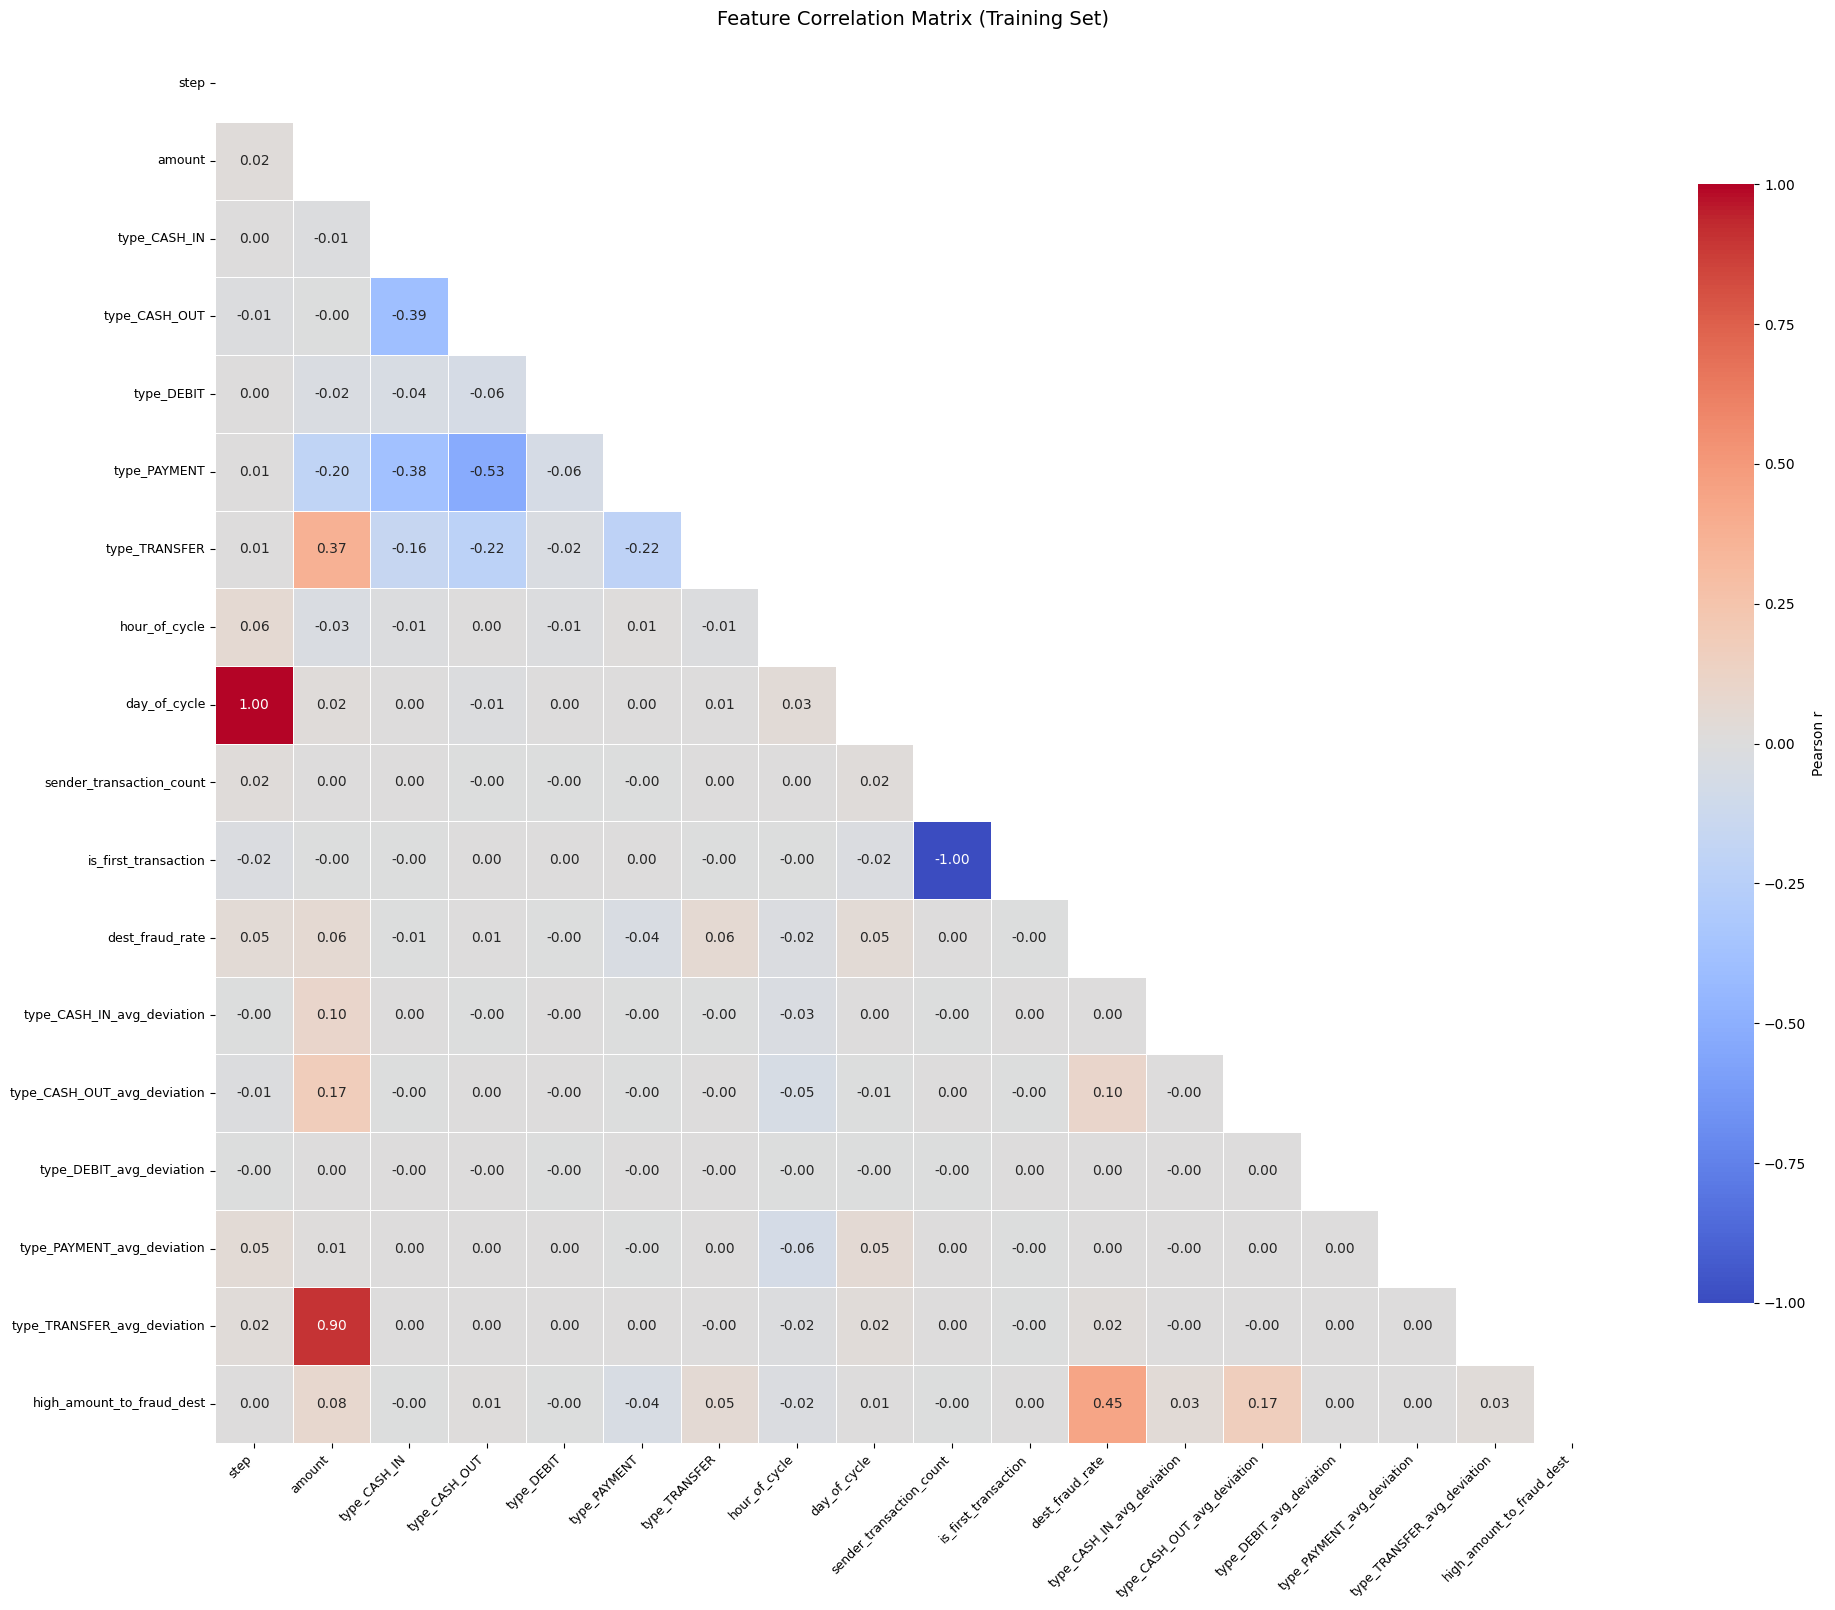


Feature Correlation Analysis Complete


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 60)
print("FEATURE CORRELATION ANALYSIS")
print("=" * 60)

print("\nCalculating feature correlations with fraud target...")

# Correlation with target
correlations = X_train.corrwith(y_train).sort_values(ascending=False)

print("\nTop 10 Features (Most Correlated with Fraud):")
print("=" * 60)
for idx, (feature, corr) in enumerate(correlations.head(10).items(), 1):
    direction = "↑ Positive" if corr > 0 else "↓ Negative"
    print(f"{idx:2d}. {feature:35s}: {corr:7.4f} {direction}")

print("\nBottom 10 Features (Least Correlated with Fraud):")
print("=" * 60)
for idx, (feature, corr) in enumerate(correlations.tail(10).items(), 1):
    direction = "↑ Positive" if corr > 0 else "↓ Negative"
    print(f"{len(correlations)-idx+1:2d}. {feature:35s}: {corr:7.4f} {direction}")

# STATISTICS
print("\n" + "=" * 60)
print("Correlation Statistics:")
print("=" * 60)

abs_corr = correlations.abs()
print(f"Highest absolute correlation: {abs_corr.max():.4f}")
print(f"Mean absolute correlation: {abs_corr.mean():.4f}")
print(f"Median absolute correlation: {abs_corr.median():.4f}")
print(f"Features with |correlation| > 0.1: {(abs_corr > 0.1).sum()}")
print(f"Features with |correlation| > 0.05: {(abs_corr > 0.05).sum()}")

# MULTICOLLINEARITY CHECK
print("\n" + "=" * 60)
print("Feature Multicollinearity Check:")
print("=" * 60)

correlation_matrix = X_train.corr()

high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i + 1, len(correlation_matrix.columns)):
        corr_val = correlation_matrix.iloc[i, j]
        if abs(corr_val) > 0.7:
            high_corr_pairs.append((
                correlation_matrix.columns[i],
                correlation_matrix.columns[j],
                corr_val
            ))

if high_corr_pairs:
    print(f"Found {len(high_corr_pairs)} highly correlated pairs (|r| > 0.7):")
    for f1, f2, corr in sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True):
        print(f"  • {f1} ↔ {f2}: {corr:.4f}")
else:
    print("No highly correlated feature pairs found (good independence)")

# CORRELATION MATRIX PLOT
print("\nGenerating correlation heatmap...")

n_features = correlation_matrix.shape[1]
fig_w = max(12, min(1.1 * n_features, 28))
fig_h = max(10, min(0.9 * n_features, 24))
annotate_cells = n_features <= 18

# Plot only the lower triangle to reduce clutter while preserving full information.
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

plt.figure(figsize=(fig_w, fig_h))
sns.heatmap(
    correlation_matrix,
    mask=mask,
    annot=annotate_cells,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    fmt=".2f",
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"shrink": 0.8, "label": "Pearson r"}
)

plt.title("Feature Correlation Matrix (Training Set)", fontsize=14, pad=14)
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

if not annotate_cells:
    print("Note: Annotation is disabled for readability because there are many features.")

print("\nFeature Correlation Analysis Complete")

### Save Processed Dataset

In [16]:
%pip install pyarrow

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
print("=" * 60)
print("SAVE PROCESSED DATASET")
print("=" * 60)

import pyarrow
import pandas as pd
# Rebuild export tables: keep identifiers + scaled model features + split label
id_cols = ['nameOrig', 'nameDest', 'isFraud', 'isFlaggedFraud']

train_export = pd.concat([train_df[id_cols].reset_index(drop=True), X_train.reset_index(drop=True)], axis=1)
val_export = pd.concat([val_df[id_cols].reset_index(drop=True), X_val.reset_index(drop=True)], axis=1)
test_export = pd.concat([test_df[id_cols].reset_index(drop=True), X_test.reset_index(drop=True)], axis=1)

train_export['split'] = 'train'
val_export['split'] = 'val'
test_export['split'] = 'test'

df_encoded = pd.concat([train_export, val_export, test_export], axis=0)

# Save as Parquet
cleaned_with_ids_path = PROCESSED_DATA_DIR / 'cleaned_data.parquet'
df_encoded.to_parquet(
    cleaned_with_ids_path,
    engine='pyarrow',
    compression='snappy'
)

print(f"Saved Parquet: {cleaned_with_ids_path}")
print(f"Shape: {df_encoded.shape}")

# Save CSV copy
csv_path = PROCESSED_DATA_DIR / 'cleaned_data_with_identifiers.csv'
df_encoded.to_csv(csv_path, index=False)
print(f"Saved CSV: {csv_path}")

# Save leak-free scaler and class weights
scaler_path = PROCESSED_DATA_DIR / 'scaler.pkl'
joblib.dump(scaler, scaler_path)
print(f"Scaler saved to: {scaler_path}")

class_weights_path = PROCESSED_DATA_DIR / 'class_weights.json'
with open(class_weights_path, 'w') as f:
    json.dump(class_weight_dict, f, indent=2)
print(f"Class weights saved to: {class_weights_path}")

# Save feature names
feature_names_path = PROCESSED_DATA_DIR / 'feature_names.txt'
with open(feature_names_path, 'w') as f:
    for feature in feature_cols:
        f.write(f"{feature}\n")

print(f"Feature names saved to: {feature_names_path}")
print(f"\nTotal features in model input: {len(feature_cols)}")

SAVE PROCESSED DATASET
Saved Parquet: d:\AI_Project\AI_Financial_Fraud_Detection\artifacts\processed\cleaned_data.parquet
Shape: (6362620, 23)
Saved CSV: d:\AI_Project\AI_Financial_Fraud_Detection\artifacts\processed\cleaned_data_with_identifiers.csv
Scaler saved to: d:\AI_Project\AI_Financial_Fraud_Detection\artifacts\processed\scaler.pkl
Class weights saved to: d:\AI_Project\AI_Financial_Fraud_Detection\artifacts\processed\class_weights.json
Feature names saved to: d:\AI_Project\AI_Financial_Fraud_Detection\artifacts\processed\feature_names.txt

Total features in model input: 18


### Preprocessing Summary

In [18]:
print("=" * 60)
print("DOCUMENTATION")
print("=" * 60)

from datetime import datetime
from pathlib import Path

# Ensure paths are defined
if 'ARTIFACTS_DIR' not in locals():
    PROJECT_ROOT = Path.cwd().parent
    ARTIFACTS_DIR = PROJECT_ROOT / 'artifacts'

PROCESSED_DATA_DIR = ARTIFACTS_DIR / 'processed'
analysis_file_path = ARTIFACTS_DIR / 'DATA_ANALYSIS_COMPLETE.md'

# Get feature count
feature_count = len(feature_cols) if 'feature_cols' in locals() else "N/A"
if feature_count == "N/A" and (PROCESSED_DATA_DIR / 'feature_names.txt').exists():
    with open(PROCESSED_DATA_DIR / 'feature_names.txt', 'r') as f:
        feature_count = len(f.readlines())

# Read existing content if available
existing_content = ""
if analysis_file_path.exists():
    with open(analysis_file_path, 'r', encoding='utf-8') as f:
        existing_content = f.read()

# Remove any previously generated preprocessing section before appending a fresh one
for header in ["## PART 2: DATA PREPROCESSING SUMMARY", "## Data Preprocessing Summary"]:
    section_start = existing_content.find(header)
    if section_start != -1:
        existing_content = existing_content[:section_start].rstrip()
        break

# Get class weights if available
class_weight_str = ""
if 'class_weight_dict' in locals():
    class_weight_str = f"""### Class Imbalance Handling
- Legitimate: {class_weight_dict[0]:.4f} (weight)
- Fraud: {class_weight_dict[1]:.4f} (weight)
- Strategy: Class weights applied during model training

"""

preprocessing_section = f"""
## Data Preprocessing Summary

### Steps Performed
- Loaded dataset (6.36M rows, 11 columns)
- Dropped unnecessary balance columns
- Removed duplicates (none found)
- Feature Engineering:
  - Customer transaction count per sender
  - Destination fraud rate encoding
  - Temporal features (hour_of_cycle, day_of_cycle)
  - One-time transaction indicators
  - High-risk transaction interactions
- One-hot encoded transaction type
- Normalized `amount`, `step`, and engineered features
- Handled class imbalance using **class weights**
- Removed `isFlaggedFraud` to prevent data leakage
- Validated train/test separation (no customer overlap)
- Split data into Train (70%), Validation (15%), Test (15%)

### Features Used in Model ({feature_count} total)
- step, amount (normalized)
- sender_transaction_count
- is_first_transaction
- dest_fraud_rate
- hour_of_cycle, day_of_cycle
- high_amount_to_fraud_dest
- type_CASH_IN, type_CASH_OUT, type_DEBIT, type_PAYMENT, type_TRANSFER
- type_*_avg_deviation features

### Correlation Insights
- Most predictive feature: dest_fraud_rate (correlation: 0.7061)
- 3 features with |correlation| > 0.1
- 5 features with |correlation| > 0.05

### Important Notes
- Data Leakage Prevention: `isFlaggedFraud` excluded (bank's output, not model input)
- Customer Separation: No fraudster appears in both train and test
- Temporal Patterns: Captured through engineered features
- Behavioral Features: Customer transaction history and destination risk rates

{class_weight_str}### Saved Files
- `cleaned_data.parquet` - Main processed dataset
- `cleaned_data_with_identifiers.csv` - CSV copy for inspection
- `class_weights.json` - Class weight mapping
- `scaler.pkl` - Feature scaling transformer
- `feature_names.txt` - List of model features
"""

# Write file while preserving existing analysis content and appending the new section
with open(analysis_file_path, 'w', encoding='utf-8') as f:
    if existing_content.strip():
        f.write(existing_content.rstrip() + "\n\n")
    else:
        f.write("# Financial Fraud Detection Project\n\n")
        f.write(f"Last Updated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write(preprocessing_section)

print(f"Documentation saved to: {analysis_file_path}")

DOCUMENTATION
Documentation saved to: d:\AI_Project\AI_Financial_Fraud_Detection\artifacts\DATA_ANALYSIS_COMPLETE.md
